In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, average_precision_score, f1_score

In [116]:
df = pd.read_csv('churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [118]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [119]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [120]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])


multicat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
ohetransform = ohe.fit_transform(df[multicat_cols])
df = pd.concat([df.drop(multicat_cols, axis=1), ohetransform], axis=1)


df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,1,53.85,108.15,1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [121]:
X = df.drop('Churn', axis=1)
y = df['Churn'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 40), (1409, 40), (5634,), (1409,))

In [122]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

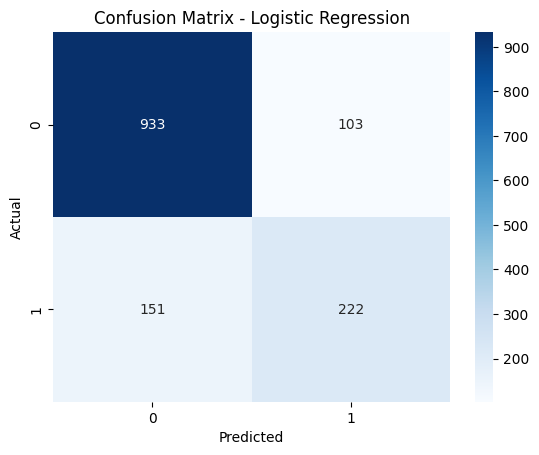

In [128]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)
lr_ypred = lr.predict(X_test)

lr_cmatrix = confusion_matrix(y_test, lr_ypred)
sns.heatmap(lr_cmatrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [129]:
lr_report = classification_report(y_test, lr_ypred)

lr_cv = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')
lr_f1score = f1_score(y_test, lr_ypred)
lr_accuracy = accuracy_score(y_test, lr_ypred)
lr_roc_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
lr_avg_precision = average_precision_score(y_test, lr.predict_proba(X_test)[:, 1])

print("Classification Report - Logistic Regression:\n", lr_report)
print("F1 Score - Logistic Regression:", lr_f1score)
print("Accuracy - Logistic Regression:", lr_accuracy)
print("ROC AUC Score - Logistic Regression:", lr_roc_auc)
print("Average Precision Score - Logistic Regression:", lr_avg_precision)
print("Logistic Regression CV ROC AUC:", lr_cv.mean())


Classification Report - Logistic Regression:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

F1 Score - Logistic Regression: 0.6361031518624641
Accuracy - Logistic Regression: 0.8197303051809794
ROC AUC Score - Logistic Regression: 0.8620687424306728
Average Precision Score - Logistic Regression: 0.6815414978105375
Logistic Regression CV ROC AUC: 0.8407733597697208


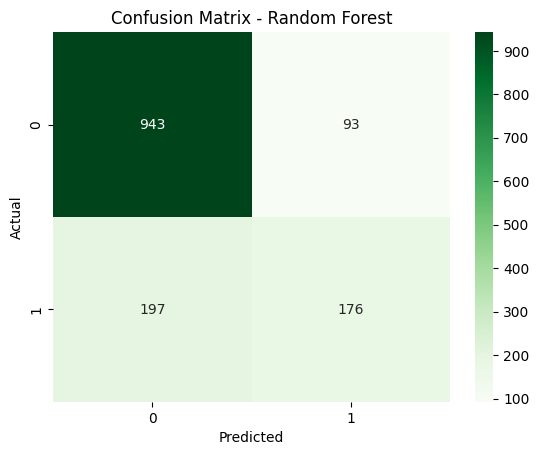

In [125]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_ypred = rf.predict(X_test)

rf_cmatrix = confusion_matrix(y_test, rf_ypred)
sns.heatmap(rf_cmatrix, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [126]:
rf_report = classification_report(y_test, rf_ypred)
rf_f1score = f1_score(y_test, rf_ypred)
rf_accuracy = accuracy_score(y_test, rf_ypred)
rf_roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
rf_avg_precision = average_precision_score(y_test, rf.predict_proba(X_test)[:, 1])

print("Classification Report - Random Forest:\n", rf_report)
print("F1 Score - Random Forest:", rf_f1score)
print("Accuracy - Random Forest:", rf_accuracy)
print("ROC AUC Score - Random Forest:", rf_roc_auc)
print("Average Precision Score - Random Forest:", rf_avg_precision)

Classification Report - Random Forest:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

F1 Score - Random Forest: 0.5482866043613707
Accuracy - Random Forest: 0.794180269694819
ROC AUC Score - Random Forest: 0.8378960634322563
Average Precision Score - Random Forest: 0.6484945720998605


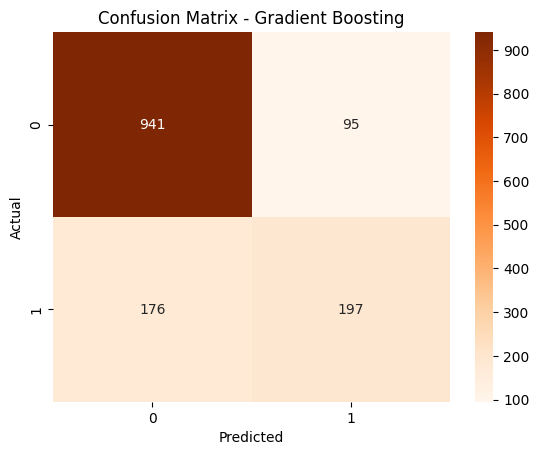

In [130]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_ypred = gb.predict(X_test)

gb_cmatrix = confusion_matrix(y_test, gb_ypred)
sns.heatmap(gb_cmatrix, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [131]:
gb_report = classification_report(y_test, gb_ypred)
gb_f1score = f1_score(y_test, gb_ypred)
gb_accuracy = accuracy_score(y_test, gb_ypred)
gb_roc_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
gb_avg_precision = average_precision_score(y_test, gb.predict_proba(X_test)[:, 1])

print("Classification Report - Gradient Boosting:\n", gb_report)
print("F1 Score - Gradient Boosting:", gb_f1score)
print("Accuracy - Gradient Boosting:", gb_accuracy)
print("ROC AUC Score - Gradient Boosting:", gb_roc_auc)
print("Average Precision Score - Gradient Boosting:", gb_avg_precision)

Classification Report - Gradient Boosting:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.53      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

F1 Score - Gradient Boosting: 0.5924812030075188
Accuracy - Gradient Boosting: 0.8076650106458482
ROC AUC Score - Gradient Boosting: 0.8594835260384859
Average Precision Score - Gradient Boosting: 0.6939990708450057
